# Tarefa 4

In [1]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
from transformers import CLIPModel, CLIPProcessor
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
if os.path.exists("./tiny-imagenet-200/"):
    print("Xa existe o directorio :)")
    train = "./tiny-imagenet-200/train/"
elif not os.path.exists("./IMagenet/"):
    print("Clonando Tiny ImageNet desde GitHub... :)")
    os.system("git clone https://github.com/seshuad/IMagenet.git")
    print("Clonado exitosamente")
    train = "./IMagenet/tiny-imagenet-200/train/"
else:
    train = "./IMagenet/tiny-imagenet-200/train/"

# Transformacións básicas (CLIP ten o seu propio redimensionado,
# pero facémolo aquí para que o DataLoader sexa eficiente)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.481, 0.457, 0.408], std=[0.268, 0.261, 0.275]) # Normalización CLIP
])

full_dataset = datasets.ImageFolder(root=train, transform=transform)

n_clases_avaliar = 50
indices = [idx for idx, (_, label) in enumerate(full_dataset.samples) if label < n_clases_avaliar]
subset_dataset = Subset(full_dataset, indices)
loader = tqdm(DataLoader(subset_dataset, batch_size=64, shuffle=False, num_workers=2))

Clonando Tiny ImageNet desde GitHub... :)
Clonado exitosamente


  0%|          | 0/391 [00:00<?, ?it/s]

# Cargamos o modelo

In [3]:
print("Cargando modelo openai/clip-vit-base-patch32...")

device = "cuda" if torch.cuda.is_available() else "cpu"

model_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor_clip = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# CLIP xa inclúe o seu propio preprocesado (resize, normalize)

Cargando modelo openai/clip-vit-base-patch32...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

# 2. Indexacion

In [4]:
def index_dataset_with_clip(model, dataloader):
    features_list = []
    labels_list = []
    model.eval()
    with torch.no_grad():
        for imgs, labels in tqdm(dataloader):
            imgs = imgs.to(device)

            # Extraer características
            outputs = model.get_image_features(pixel_values=imgs)

            # ERRO FIX: Se 'outputs' é un obxecto e non un tensor, extraemos o tensor
            if hasattr(outputs, "pooler_output"):
                img_features = outputs.pooler_output
            else:
                img_features = outputs

            # Agora que é un tensor, xa podemos normalizar
            img_features = F.normalize(img_features, p=2, dim=1)

            features_list.append(img_features.cpu())
            labels_list.append(labels)

    return torch.cat(features_list), torch.cat(labels_list)

print("\nIndexando o dataset con CLIP (Imaxes)...")
feats_visual, labels_all = index_dataset_with_clip(model_clip, loader)


Indexando o dataset con CLIP (Imaxes)...



100%|██████████| 391/391 [01:24<00:00,  4.61it/s]


# 3. Avaliación

In [5]:
def text_search(query_text, model, visual_features, k=5):
    model.eval()
    with torch.no_grad():
        # Tokenizar
        inputs = processor_clip(text=[query_text], return_tensors="pt", padding=True).to(device)

        # Extraer características do texto
        outputs = model.get_text_features(**inputs)

        # ERRO FIX: Se é un obxecto, extraemos o tensor
        if hasattr(outputs, "pooler_output"):
            text_features = outputs.pooler_output
        else:
            text_features = outputs

        text_features = F.normalize(text_features, p=2, dim=1)

        # Calcular similitude
        similarities = torch.mm(text_features, visual_features.t().to(device))

        values, indices = torch.topk(similarities, k)
        return indices[0].cpu().numpy(), values[0].cpu().numpy()

def evaluate_clip(features, labels, k=5):
    sim_matrix = torch.mm(features, features.t())
    sim_matrix.fill_diagonal_(-1)
    _, topk_indices = torch.topk(sim_matrix, k, dim=1)

    query_labels = labels.view(-1, 1).expand_as(topk_indices)
    retrieved_labels = labels[topk_indices]

    precision = (query_labels == retrieved_labels).float().mean().item()
    return precision

p_clip = evaluate_clip(feats_visual, labels_all, k=5)
print(f"\nCLIP (Visual) -> Precision@5: {p_clip:.4f}")



CLIP (Visual) -> Precision@5: 0.5782


# Visualización do Buscador Textual

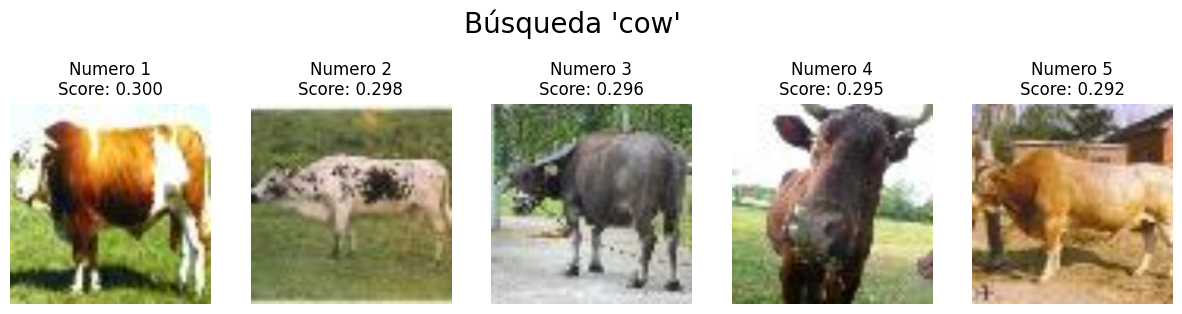

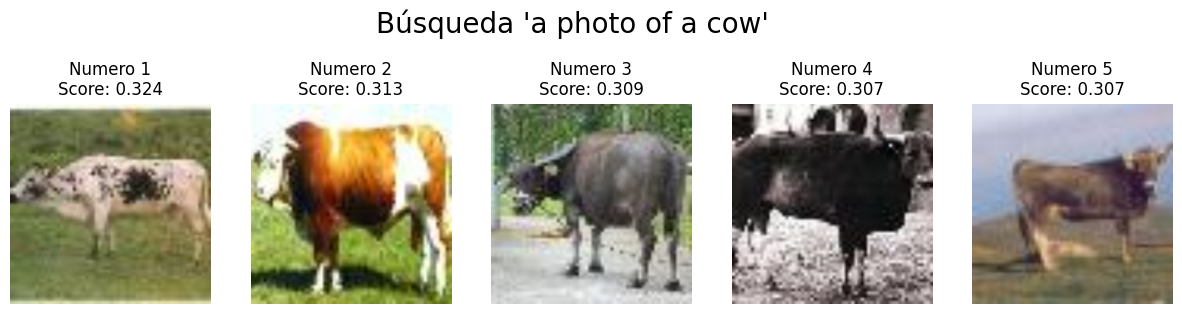

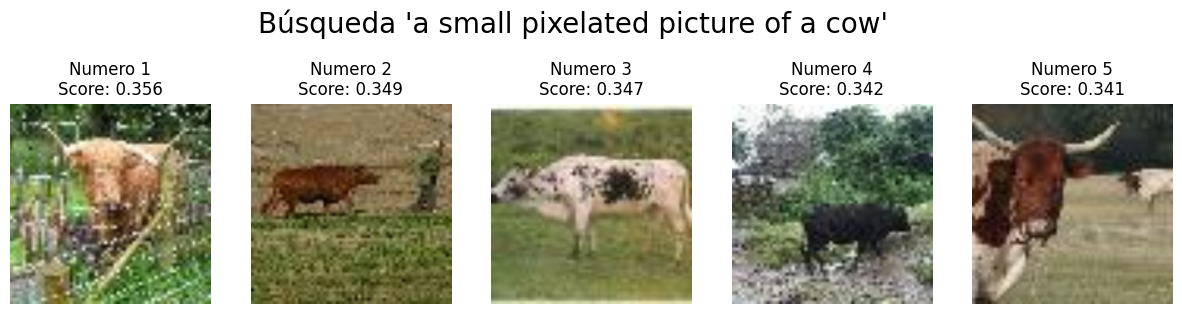

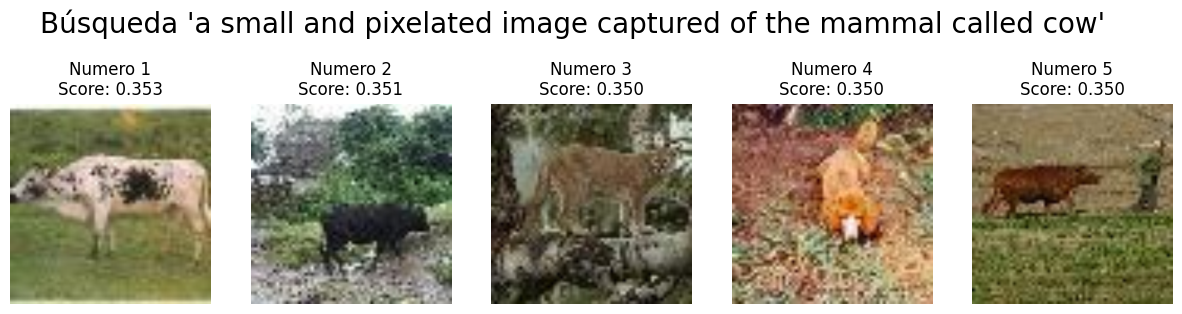

In [18]:
def visualize_results(query, indices, scores, dataset):
    n = len(indices)
    plt.figure(figsize=(15, 4))
    plt.suptitle(f"Búsqueda '{query}'", fontsize=20)

    for i in range(n):
        idx = indices[i]
        img, _ = dataset[idx]

        mean = np.array([0.48145466, 0.4578275, 0.40821073])
        std = np.array([0.26862954, 0.26130258, 0.27577711])

        # Dentro do bucle:
        img = img.permute(1, 2, 0).numpy()
        img = std * img + mean # Desnormalización exacta
        img = np.clip(img, 0, 1)

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(f"Numero {i+1}\nScore: {scores[i]:.3f}")
        plt.axis('off')
    plt.show()

# Probas do buscador
queries = [ "cow", "a photo of a cow", "a small pixelated picture of a cow", "a small and pixelated image captured of the mammal called cow"]

for q in queries:
    idx_res, score_res = text_search(q, model_clip, feats_visual, k=5)
    visualize_results(q, idx_res, score_res, subset_dataset)